# OHCA Events per County: Spatial Autocorrelation in Google Colab

This notebook uses the OHCA training dataset and U.S. county boundaries to:

1. Convert OHCA records with latitude/longitude into spatial points.
2. Spatially join points to county polygons.
3. Count OHCA events per county.
4. Run Global Moran's I and Local Moran's I / LISA.
5. Map event counts and statistically significant clusters.

**Note:** Moran's I requires a variable, not just coordinates. Here the variable is `ohca_event_count`, the number of OHCA events in each county.

## 1. Install Packages

Run this cell in Google Colab. It installs the geospatial and spatial-statistics libraries used in the workshop.

In [1]:
!pip -q install geopandas libpysal esda mapclassify matplotlib folium

In [6]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


## 2. Import Libraries and Set File Paths

For Colab, upload the `data` folder or mount Google Drive and update `DATA_DIR` if needed. The shapefile must keep all sidecar files together: `.shp`, `.shx`, `.dbf`, `.prj`, and `.cpg`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import Queen, KNN, lag_spatial
from esda.moran import Moran, Moran_Local

# Local path works on Jenny's computer. In Colab, upload/copy data to /content/data or adjust this path.
LOCAL_DATA_DIR = Path('/Users/jenny/Desktop/Workshop/data')
COLAB_DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Workshop/data')
DATA_DIR = COLAB_DATA_DIR if COLAB_DATA_DIR.exists() else LOCAL_DATA_DIR

OHCA_CSV = DATA_DIR/'ohca_connected_data.csv'
COUNTY_SHP = DATA_DIR/'cb_2018_us_county_500k'/'cb_2018_us_county_500k - Copy.shp'

print('OHCA file:', OHCA_CSV)
print('County shapefile:', COUNTY_SHP)

OHCA file: /Users/jenny/Desktop/Workshop/data/ohca_connected_data.csv
County shapefile: /Users/jenny/Desktop/Workshop/data/cb_2018_us_county_500k/cb_2018_us_county_500k - Copy.shp


## 3. Load OHCA Records and Create Point Geometry

The OHCA file has latitude and longitude columns. We convert the table into a `GeoDataFrame` using WGS84 coordinates (`EPSG:4326`).

In [2]:
lat_col = 'scene_gps_latitude_escene.11'
lon_col = 'scene_gps_longitude_escene.11'

ohca = pd.read_csv(OHCA_CSV)
ohca[lat_col] = pd.to_numeric(ohca[lat_col], errors='coerce')
ohca[lon_col] = pd.to_numeric(ohca[lon_col], errors='coerce')
ohca = ohca.dropna(subset=[lat_col, lon_col]).copy()

ohca_points = gpd.GeoDataFrame(
    ohca,
    geometry=gpd.points_from_xy(ohca[lon_col], ohca[lat_col]),
    crs='EPSG:4326'
)

print('OHCA records with valid coordinates:', len(ohca_points))
ohca_points[[lat_col, lon_col, 'incident_date']].head()

OHCA records with valid coordinates: 6005


,scene_gps_latitude_escene.11,scene_gps_longitude_escene.11,incident_date
0,33.720626,-84.233276,2020-05-16
1,34.853186,-84.343906,2021-07-29
2,32.108308,-81.551837,2020-10-26
3,33.716513,-84.317138,2019-11-24
4,33.942115,-83.413094,2021-12-22


## 4. Quick Map of OHCA Point Locations

Before joining the points to county polygons, it is useful to plot the point layer by itself. This helps confirm that the coordinates are in the expected study area and that latitude/longitude were assigned correctly.

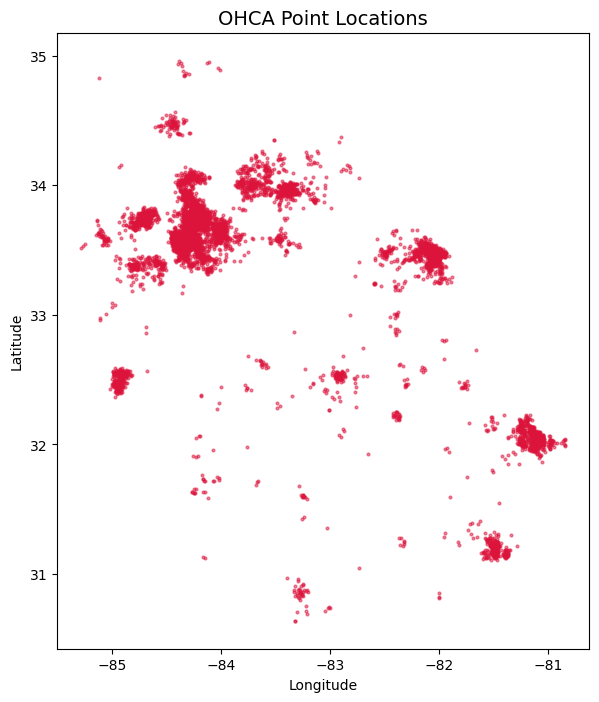

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
ohca_points.plot(
    ax=ax,
    markersize=4,
    alpha=0.5,
    color='crimson'
)
ax.set_title('OHCA Point Locations', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

## 5. Load Georgia County Boundaries and Overlay OHCA Points

Load U.S. county polygons, filter to **Georgia** (`STATEFP = '13'`), and overlay OHCA points on the county map so participants can visually verify both layers before spatial join.

Georgia counties: 159


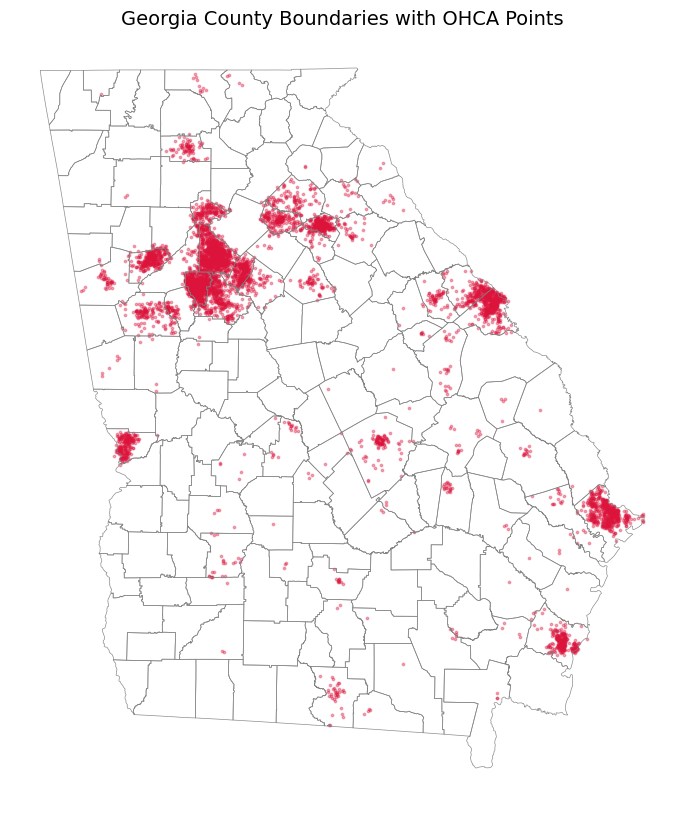

,GEOID,NAME,geometry
70,13009,Baldwin,"POLYGON ((-83.42674 33.18273, -83.42496 33.182..."
71,13027,Brooks,"MULTIPOLYGON (((-83.33829 30.63972, -83.33708 ..."
72,13103,Effingham,"POLYGON ((-81.54801 32.48929, -81.5455 32.4938..."
73,13121,Fulton,"POLYGON ((-84.84931 33.51318, -84.84429 33.514..."
74,13141,Hancock,"POLYGON ((-83.27522 33.19132, -83.27413 33.196..."


In [4]:
county = gpd.read_file(COUNTY_SHP).to_crs('EPSG:4326')

county_id_col = 'GEOID'
county_name_col = 'NAME'
state_col = 'STATEFP'

if state_col not in county.columns:
    raise ValueError('STATEFP column not found in county file. Cannot filter to Georgia.')

# Georgia counties only
county_study = county[county[state_col].astype(str) == '13'][[county_id_col, county_name_col, 'geometry']].copy()

print('Georgia counties:', len(county_study))

fig, ax = plt.subplots(figsize=(10, 10))
county_study.boundary.plot(ax=ax, linewidth=0.5, color='gray', alpha=0.9)
ohca_points.plot(ax=ax, markersize=3, color='crimson', alpha=0.35)
ax.set_title('Georgia County Boundaries with OHCA Points', fontsize=14)
ax.axis('off')
plt.show()

county_study.head()

In [5]:
print('County columns:', [c for c in county.columns if c in ['STATEFP', 'COUNTYFP', 'GEOID', 'NAME']])
county_study[[county_id_col, county_name_col]].head()

County columns: ['STATEFP', 'COUNTYFP', 'GEOID', 'NAME']


,GEOID,NAME
70,13009,Baldwin
71,13027,Brooks
72,13103,Effingham
73,13121,Fulton
74,13141,Hancock


In [6]:
# Georgia county layer and OHCA points are now ready for spatial join.

## 6. Spatial Join: OHCA Points to Georgia Counties

Now use a direct GeoPandas spatial join between point and polygon layers:

`gpd.sjoin(points_gdf, polygons_gdf, predicate="within")`

This assigns each OHCA point to the Georgia county polygon it falls within.

In [7]:
joined = gpd.sjoin(
    ohca_points,
    county_study[[county_id_col, county_name_col, 'geometry']],
    how='left',
    predicate='within'
)

matched = joined[county_id_col].notna().sum()
unmatched = len(joined) - matched
print(f'OHCA points matched with gpd.sjoin(..., predicate="within"): {matched} of {len(joined)}')
print(f'Unmatched points: {unmatched}')
joined[[lat_col, lon_col, county_id_col, county_name_col]].head()

OHCA points matched with gpd.sjoin(..., predicate="within"): 5963 of 6005
Unmatched points: 42


,scene_gps_latitude_escene.11,scene_gps_longitude_escene.11,GEOID,NAME
0,33.720626,-84.233276,13089,DeKalb
1,34.853186,-84.343906,13111,Fannin
2,32.108308,-81.551837,13029,Bryan
3,33.716513,-84.317138,13089,DeKalb
4,33.942115,-83.413094,13059,Clarke


## 7. Count OHCA Events per County

The analysis variable for spatial autocorrelation is `ohca_event_count`.

This step keeps only Georgia counties that received at least one OHCA point in the spatial join.

In [8]:
event_counts = (
    joined.dropna(subset=[county_id_col])
    .groupby([county_id_col, county_name_col])
    .size()
    .rename('ohca_event_count')
    .reset_index()
)

# Standardize ID dtype before filtering/merging.
event_counts[county_id_col] = event_counts[county_id_col].astype(str)
county_study[county_id_col] = county_study[county_id_col].astype(str)

analysis_ids = event_counts[county_id_col].unique()
county_counts = county_study[county_study[county_id_col].isin(analysis_ids)].copy()
county_counts = county_counts.merge(event_counts, on=[county_id_col, county_name_col], how='left')
county_counts['ohca_event_count'] = county_counts['ohca_event_count'].fillna(0).astype(int)

print('Georgia counties with >=1 OHCA point:', len(county_counts))
county_counts[[county_name_col, 'ohca_event_count']].sort_values('ohca_event_count', ascending=False).head()

Georgia counties with >=1 OHCA point: 97


,NAME,ohca_event_count
65,DeKalb,865
41,Clayton,830
13,Chatham,504
23,Richmond,394
39,Henry,344


## 8. Map OHCA Event Counts

This choropleth shows the raw number of OHCA events per Georgia county. For research, a rate per population is often better than a raw count.

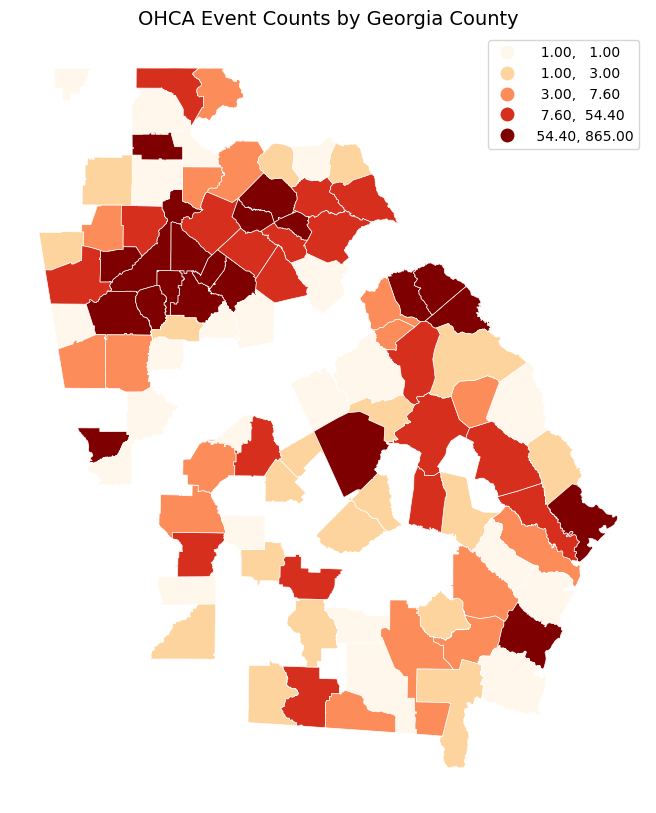

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
county_counts.plot(
    column='ohca_event_count',
    cmap='OrRd',
    scheme='quantiles',
    k=5,
    legend=True,
    linewidth=0.5,
    edgecolor='white',
    ax=ax
)
ax.set_title('OHCA Event Counts by Georgia County', fontsize=14)
ax.axis('off')
plt.show()

## 9. Create Spatial Weights

Spatial autocorrelation needs a definition of neighboring areas. We start with Queen contiguity, where counties are neighbors if they touch. If there are disconnected polygons, the notebook uses 4-nearest-neighbor weights as a practical fallback.

In [10]:
analysis_gdf = county_counts.reset_index(drop=True).copy()

w_queen = Queen.from_dataframe(analysis_gdf, use_index=False)
print('Queen islands:', len(w_queen.islands))

if len(w_queen.islands) > 0:
    print('Using KNN weights because some counties have no Queen neighbors in this subset.')
    w = KNN.from_dataframe(analysis_gdf, k=4)
    weight_method = '4-nearest neighbors'
else:
    w = w_queen
    weight_method = 'Queen contiguity'

w.transform = 'r'
print('Weight method:', weight_method)
print('Number of areas:', w.n)

Queen islands: 1
Using KNN weights because some counties have no Queen neighbors in this subset.
Weight method: 4-nearest neighbors
Number of areas: 97


/opt/anaconda3/envs/ezr/lib/python3.10/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There is 1 island with id: 53.
  W.__init__(self, neighbors, ids=ids, **kw)


## 10. Global Moran's I

Global Moran's I tests whether high or low OHCA event counts are spatially clustered across the full study area.

- Positive Moran's I: similar values cluster near each other.
- Near zero Moran's I: little spatial pattern.
- Negative Moran's I: neighboring areas tend to be dissimilar.

The p-value tells you whether the observed spatial pattern is statistically significant.
The z-score tells you how far your observed Moran’s I is from what would be expected under randomness.

In [11]:
y = analysis_gdf['ohca_event_count'].astype(float).values

moran = Moran(y, w, permutations=999)

print(f"Global Moran's I: {moran.I:.4f}")
print(f'Permutation p-value: {moran.p_sim:.4f}')
print(f'Z score: {moran.z_sim:.4f}')

Global Moran's I: 0.3392
Permutation p-value: 0.0010
Z score: 5.6452


## 10. Global Moran's I

-- Global Moran’s I = 0.3392;
Positive and moderately large, so counties with similar OHCA counts tend to be near each other (spatial clustering).

-- Expected I = -0.0104;
Under spatial randomness, Moran’s I should be around this value (near zero, slightly negative due to sample size/weights structure).

-- Permutation p-value = 0.0010;
Very significant (< 0.05), meaning this pattern is highly unlikely to be random.



## 11. Local Moran's I / LISA Clusters

Local Moran's I identifies where clusters occur. Common labels are:

- High-High: high-count county near high-count neighbors
- Low-Low: low-count county near low-count neighbors
- High-Low: high-count county near low-count neighbors
- Low-High: low-count county near high-count neighbors

In [12]:
lisa = Moran_Local(y, w, permutations=999)

analysis_gdf['local_moran_i'] = lisa.Is
analysis_gdf['local_moran_p'] = lisa.p_sim
analysis_gdf['spatial_lag_count'] = lag_spatial(w, y)

def lisa_cluster(q, p, alpha=0.05):
    if p >= alpha:
        return 'Not significant'
    return {
        1: 'High-High',
        2: 'Low-High',
        3: 'Low-Low',
        4: 'High-Low'
    }.get(q, 'Not significant')

analysis_gdf['lisa_cluster'] = [lisa_cluster(q, p) for q, p in zip(lisa.q, lisa.p_sim)]

analysis_gdf['lisa_cluster'].value_counts()

lisa_cluster
Not significant    87
High-High           6
Low-High            2
High-Low            1
Low-Low             1
Name: count, dtype: int64

## 12. Map LISA Cluster Results

Saved LISA map PNG: /Users/jenny/Desktop/Workshop/data/outputs/county_lisa_cluster_map.png


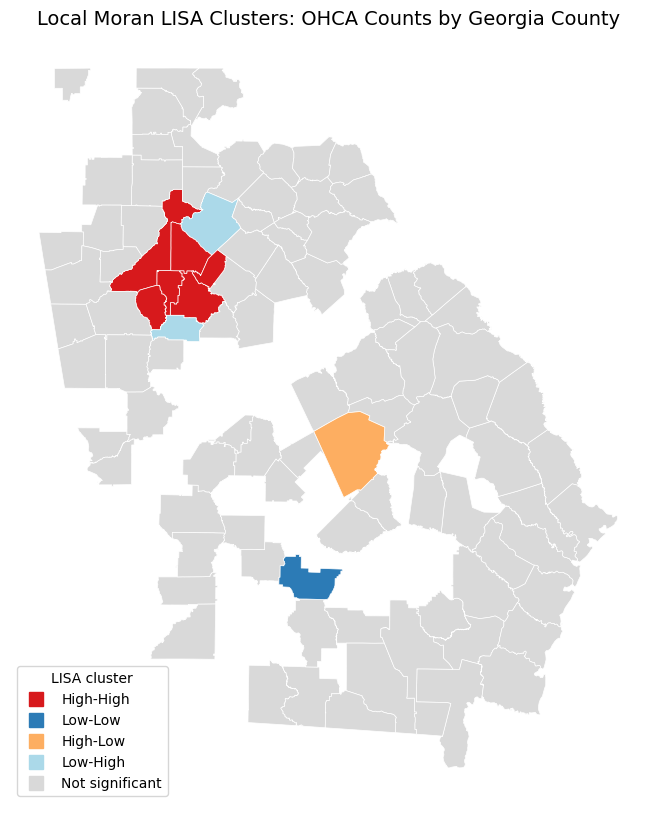

In [13]:
cluster_colors = {
    'High-High': '#d7191c',
    'Low-Low': '#2c7bb6',
    'High-Low': '#fdae61',
    'Low-High': '#abd9e9',
    'Not significant': '#d9d9d9'
}

fig, ax = plt.subplots(figsize=(10, 10))
analysis_gdf.plot(
    color=analysis_gdf['lisa_cluster'].map(cluster_colors),
    linewidth=0.5,
    edgecolor='white',
    ax=ax
)

handles = [
    plt.Line2D([0], [0], marker='s', linestyle='', markersize=10, color=color, label=label)
    for label, color in cluster_colors.items()
]
ax.legend(handles=handles, title='LISA cluster', loc='lower left')
ax.set_title('Local Moran LISA Clusters: OHCA Counts by Georgia County', fontsize=14)
ax.axis('off')

# Save a slide-ready map image.
OUTPUT_DIR = DATA_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
lisa_png = OUTPUT_DIR / 'county_lisa_cluster_map.png'
fig.savefig(lisa_png, dpi=300, bbox_inches='tight')
print('Saved LISA map PNG:', lisa_png)

plt.show()

## 13. Export Results

These outputs can be used for slides, follow-up mapping, or participant exercises.

In [14]:
OUTPUT_DIR = DATA_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

csv_out = OUTPUT_DIR / 'county_ohca_spatial_autocorrelation_results.csv'
geojson_out = OUTPUT_DIR / 'county_ohca_spatial_autocorrelation_results.geojson'

analysis_gdf.drop(columns='geometry').to_csv(csv_out, index=False)
analysis_gdf.to_file(geojson_out, driver='GeoJSON')

print('Saved CSV:', csv_out)
print('Saved GeoJSON:', geojson_out)

Saved CSV: /Users/jenny/Desktop/Workshop/data/outputs/county_ohca_spatial_autocorrelation_results.csv
Saved GeoJSON: /Users/jenny/Desktop/Workshop/data/outputs/county_ohca_spatial_autocorrelation_results.geojson


## Discussion Questions

1. What does a significant Global Moran's I tell us about OHCA event counts?
2. Where are High-High clusters located, and how might public health researchers interpret them?
3. Why might raw counts be misleading compared with population-adjusted rates?
4. How would the results change if we used census tracts instead of counties?